In [1]:
import sys
!{sys.executable} -m pip install pandas

=== Calibration Results ===
  X-axis  b = -0.0419 m/s²   s = 0.9946   (full)
  Y-axis  b = -0.2080 m/s²   s = 1.0000   (neg-only)
  Z-axis  b = -0.3484 m/s²   s = 1.0021   (full)

=== Noise Results ===
  Predicted RMS: 1.5355 mm/s²  (0.157 mg)
  Measured X RMS: 67.4735 mm/s²  (6.88 mg)
  Measured Y RMS: 66.7419 mm/s²  (6.80 mg)
  Measured Z RMS: 68.8927 mm/s²  (7.02 mg)


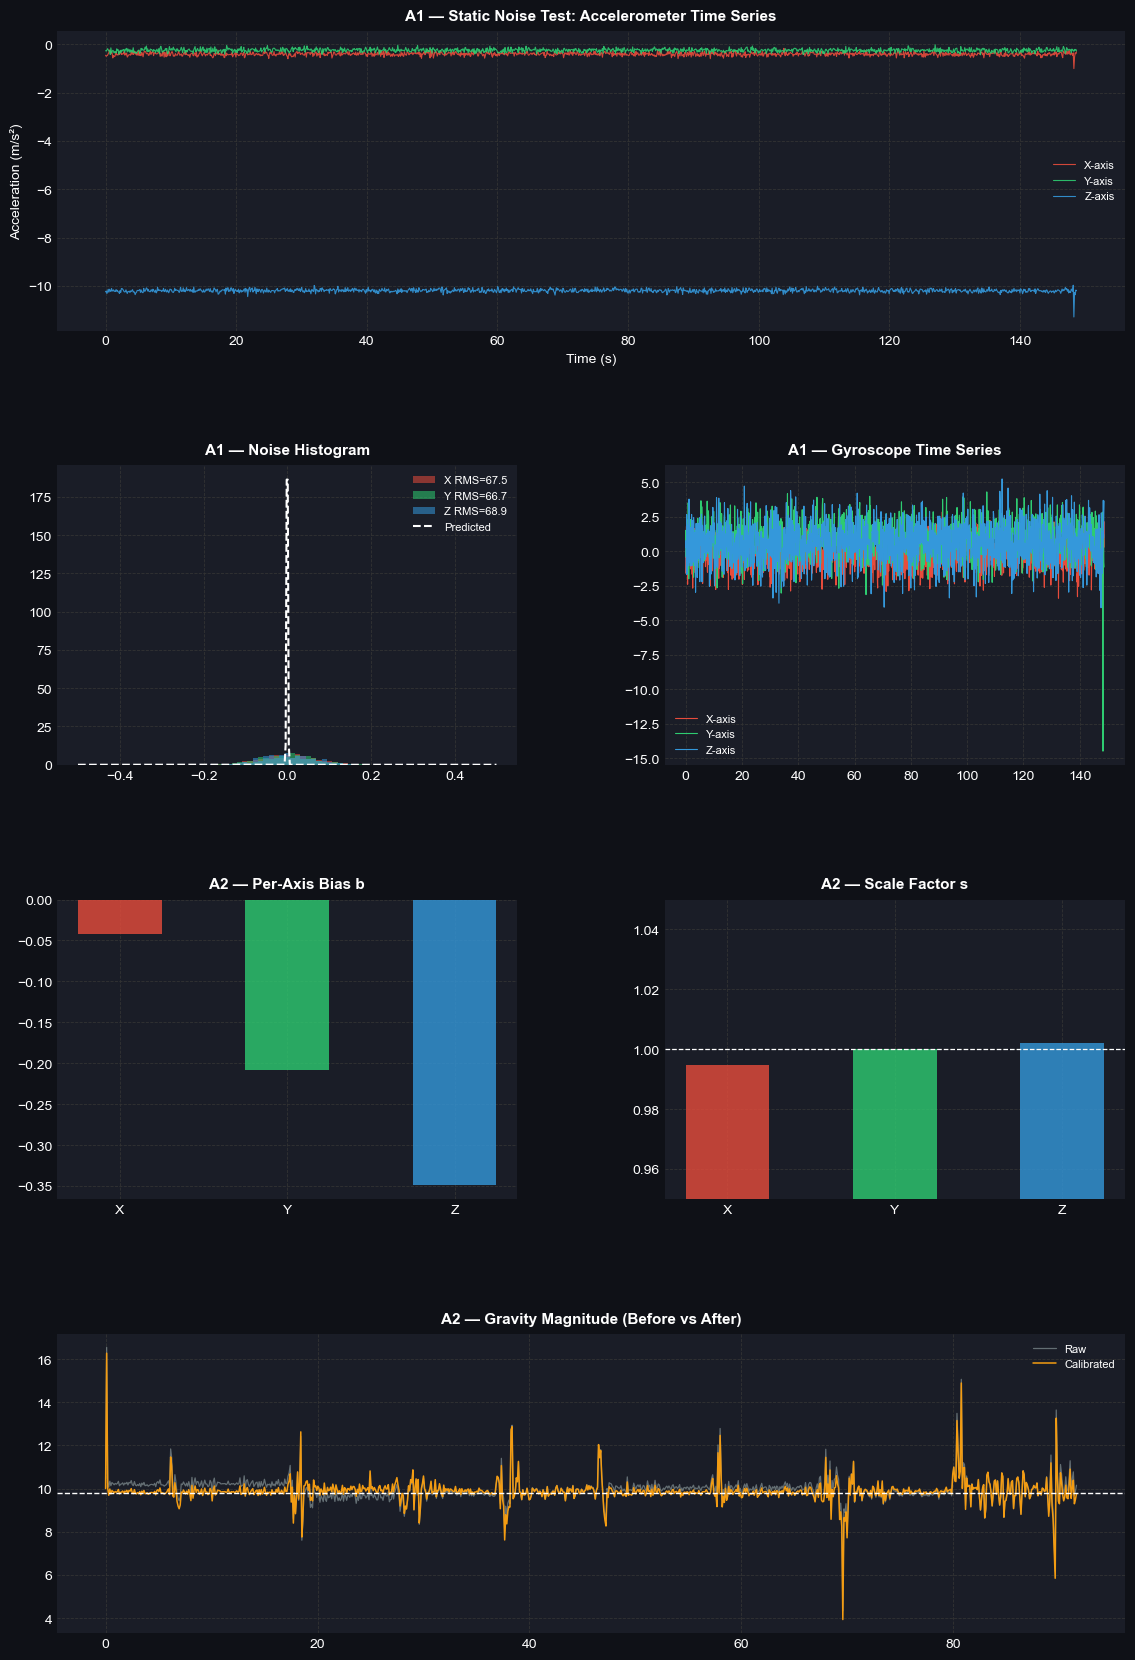

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm
import sys

# ── constants ──────────────────────────────────────────────────────────────────
g  = 9.81          # m/s²
fs = 10.0          # sample rate Hz (measured from data)

COLORS = {
    'X': '#E74C3C',
    'Y': '#2ECC71',
    'Z': '#3498DB',
    'mag_raw': '#95A5A6',
    'mag_cal': '#F39C12',
}

# ══════════════════════════════════════════════════════════════════════════════
# 1. LOAD DATA
# ══════════════════════════════════════════════════════════════════════════════
def load_imu(path):
    # Note: Ensure ABC1.csv and A2.csv are in the same folder as this notebook
    df = pd.read_csv(path)
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%Y/%m/%d %H:%M:%S.%f')
    df['t'] = (df['Timestamp'] - df['Timestamp'].iloc[0]).dt.total_seconds()
    # Convert milli-g → m/s²
    for ax in ['AccX', 'AccY', 'AccZ']:\
        df[f'{ax}_ms2'] = df[ax] / 1000 * g
    return df

# Attempt to load data
try:
    df_a1 = load_imu('ABC1.csv')   # A1 — Static Noise Test
    df_a2 = load_imu('A2.csv')     # A2 — Six-Face Calibration
except FileNotFoundError as e:
    print(f"Error: Could not find data file. {e}")
    raise

# ══════════════════════════════════════════════════════════════════════════════
# 2. SIX-FACE CALIBRATION — detect stable windows & compute b / s
# ══════════════════════════════════════════════════════════════════════════════
df_a2['mag'] = np.sqrt(df_a2['AccX_ms2']**2 +
                        df_a2['AccY_ms2']**2 +
                        df_a2['AccZ_ms2']**2)

win = int(fs)  # 1-second window
df_a2['roll_std'] = df_a2['mag'].rolling(win, center=True).std()
stable = df_a2[df_a2['roll_std'] < 0.5].copy()

def dominant_face(row):
    vals = {
        'X+': row['AccX_ms2'], 'X-': -row['AccX_ms2'],
        'Y+': row['AccY_ms2'], 'Y-': -row['AccY_ms2'],
        'Z+': row['AccZ_ms2'], 'Z-': -row['AccZ_ms2'],
    }
    return max(vals, key=vals.get)

stable['face'] = stable.apply(dominant_face, axis=1)
face_means = stable.groupby('face')[['AccX_ms2', 'AccY_ms2', 'AccZ_ms2']].mean()

def axis_cal(pos_face, neg_face, col):
    has_pos = pos_face in face_means.index
    has_neg = neg_face in face_means.index
    if has_pos and has_neg:
        ap = face_means.loc[pos_face, col]
        an = face_means.loc[neg_face, col]
        b  = (ap + an) / 2
        s  = (ap - an) / (2 * g)
        return b, s, 'full'
    elif has_pos:
        ap = face_means.loc[pos_face, col]
        return ap - g, 1.0, 'pos-only'
    elif has_neg:
        an = face_means.loc[neg_face, col]
        return an + g, 1.0, 'neg-only'
    return 0.0, 1.0, 'missing'

cal = {
    'X': axis_cal('X+', 'X-', 'AccX_ms2'),
    'Y': axis_cal('Y+', 'Y-', 'AccY_ms2'),
    'Z': axis_cal('Z+', 'Z-', 'AccZ_ms2'),
}

print("=== Calibration Results ===")
for ax, (b, s, mode) in cal.items():
    print(f"  {ax}-axis  b = {b:+.4f} m/s²   s = {s:.4f}   ({mode})")

for df in [df_a1, df_a2]:
    for ax in ['X', 'Y', 'Z']:
        b, s, _ = cal[ax]
        df[f'Acc{ax}_cal'] = (df[f'Acc{ax}_ms2'] - b) / s

df_a2['mag_cal'] = np.sqrt(df_a2['AccX_cal']**2 +
                            df_a2['AccY_cal']**2 +
                            df_a2['AccZ_cal']**2)

# ══════════════════════════════════════════════════════════════════════════════
# 3. A1 NOISE STATISTICS
# ══════════════════════════════════════════════════════════════════════════════
noise_rms = {ax: df_a1[f'Acc{ax}_ms2'].std() for ax in ['X', 'Y', 'Z']}
NSD_g_rthz   = 70e-6            
NSD_ms2_rthz = NSD_g_rthz * g  
bw           = fs / 2           
predicted_rms = NSD_ms2_rthz * np.sqrt(bw)

print("\n=== Noise Results ===")
print(f"  Predicted RMS: {predicted_rms*1000:.4f} mm/s²  ({predicted_rms/g*1000:.3f} mg)")
for ax in ['X', 'Y', 'Z']:
    print(f"  Measured {ax} RMS: {noise_rms[ax]*1000:.4f} mm/s²  ({noise_rms[ax]/g*1000:.2f} mg)")

# ══════════════════════════════════════════════════════════════════════════════
# 4. PLOTTING
# ══════════════════════════════════════════════════════════════════════════════

# NOTE: Removed matplotlib.use('Agg') to allow VS Code to display plots inline.

plt.style.use('seaborn-v0_8-darkgrid')
fig = plt.figure(figsize=(12, 18)) # Reduced size slightly for better notebook fit
fig.patch.set_facecolor('#0F1117')
plt.rcParams.update({
    'text.color': 'white', 'axes.labelcolor': 'white',
    'xtick.color': 'white', 'ytick.color': 'white',
    'axes.titlecolor': 'white', 'figure.facecolor': '#0F1117',
})

gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.32,
                       left=0.07, right=0.96, top=0.94, bottom=0.05)
AX_COLOR = '#1A1D27'

def style_ax(ax, title):
    ax.set_facecolor(AX_COLOR)
    ax.set_title(title, color='white', fontsize=11, fontweight='bold', pad=8)
    ax.tick_params(colors='white')
    for sp in ax.spines.values():
        sp.set_edgecolor('#444')
    
    # Check for labels to avoid the "No artists with labels" warning
    handles, labels = ax.get_legend_handles_labels()
    if labels:
        ax.legend(facecolor='#222', edgecolor='#555', labelcolor='white', fontsize=8)
    
    ax.grid(color='#333', linestyle='--', linewidth=0.6)

# Plot 1: A1 Accelerometer
ax1 = fig.add_subplot(gs[0, :])
for ax_name, col in [('X', 'AccX_ms2'), ('Y', 'AccY_ms2'), ('Z', 'AccZ_ms2')]:
    ax1.plot(df_a1['t'], df_a1[col], lw=0.8, color=COLORS[ax_name], label=f'{ax_name}-axis', alpha=0.9)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Acceleration (m/s²)')
style_ax(ax1, 'A1 — Static Noise Test: Accelerometer Time Series')

# Plot 2: Noise Histogram
ax2 = fig.add_subplot(gs[1, 0])
bins = np.linspace(-0.5, 0.5, 80)
for ax_name, col in [('X', 'AccX_ms2'), ('Y', 'AccY_ms2'), ('Z', 'AccZ_ms2')]:
    residuals = df_a1[col] - df_a1[col].mean()
    ax2.hist(residuals, bins=bins, alpha=0.55, color=COLORS[ax_name], density=True,
             label=f'{ax_name} RMS={noise_rms[ax_name]*1000:.1f}')
x_g = np.linspace(-0.5, 0.5, 400)
ax2.plot(x_g, norm.pdf(x_g, 0, predicted_rms), 'w--', lw=1.5, label='Predicted')
style_ax(ax2, 'A1 — Noise Histogram')

# Plot 3: A1 Gyroscope
ax3 = fig.add_subplot(gs[1, 1])
for ax_name, col in [('X', 'GyrX'), ('Y', 'GyrY'), ('Z', 'GyrZ')]:
    ax3.plot(df_a1['t'], df_a1[col], lw=0.8, color=COLORS[ax_name], label=f'{ax_name}-axis')
style_ax(ax3, 'A1 — Gyroscope Time Series')

# Plot 4: Bias Bar Chart
ax4 = fig.add_subplot(gs[2, 0])
axes_labels = ['X', 'Y', 'Z']
biases = [cal[a][0] for a in axes_labels]
notes  = [cal[a][2] for a in axes_labels]
bars = ax4.bar(np.arange(3), biases, 0.5, color=[COLORS[a] for a in axes_labels], alpha=0.8)
ax4.set_xticks(np.arange(3))
ax4.set_xticklabels(['X', 'Y', 'Z'])
style_ax(ax4, 'A2 — Per-Axis Bias b')

# Plot 5: Scale Factor
ax5 = fig.add_subplot(gs[2, 1])
scales = [cal[a][1] for a in axes_labels]
ax5.bar(np.arange(3), scales, 0.5, color=[COLORS[a] for a in axes_labels], alpha=0.8)
ax5.set_ylim(0.95, 1.05)
ax5.axhline(1.0, color='white', lw=0.9, ls='--')
ax5.set_xticks(np.arange(3))
ax5.set_xticklabels(['X', 'Y', 'Z'])
style_ax(ax5, 'A2 — Scale Factor s')

# Plot 6: Gravity Magnitude
ax6 = fig.add_subplot(gs[3, :])
ax6.plot(df_a2['t'], df_a2['mag'], lw=0.9, color=COLORS['mag_raw'], label='Raw', alpha=0.6)
ax6.plot(df_a2['t'], df_a2['mag_cal'], lw=1.1, color=COLORS['mag_cal'], label='Calibrated')
ax6.axhline(g, color='white', lw=1.0, ls='--')
style_ax(ax6, 'A2 — Gravity Magnitude (Before vs After)')

plt.savefig('module_A_accelerometer.png', dpi=150, bbox_inches='tight')
plt.show() # This will now display the image in the cell